In [1]:
#Homework 8
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

In [109]:
import time

#print(np.__version__)
#print(tf.__version__)

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.

In [3]:
# Q1 Data generation
N_sin = 10000
N_sample = 100
np.random.seed(42)

t = np.linspace(0, 4 * np.pi, N_sample)  
A = np.random.uniform(0.5, 1.5, size=(N_sin, 1))      
omega = np.random.uniform(0.5, 2.0, size=(N_sin, 1))  
phi = np.random.uniform(0, 2 * np.pi, size=(N_sin, 1))

clean_curve = A * np.sin(omega * t + phi)

# Add Gaussian noise (sigma = 0.2)
sigma = 0.2
noise = np.random.normal(0, sigma, size=(N_sin, N_sample))

noisy_curve = clean_curve + noise

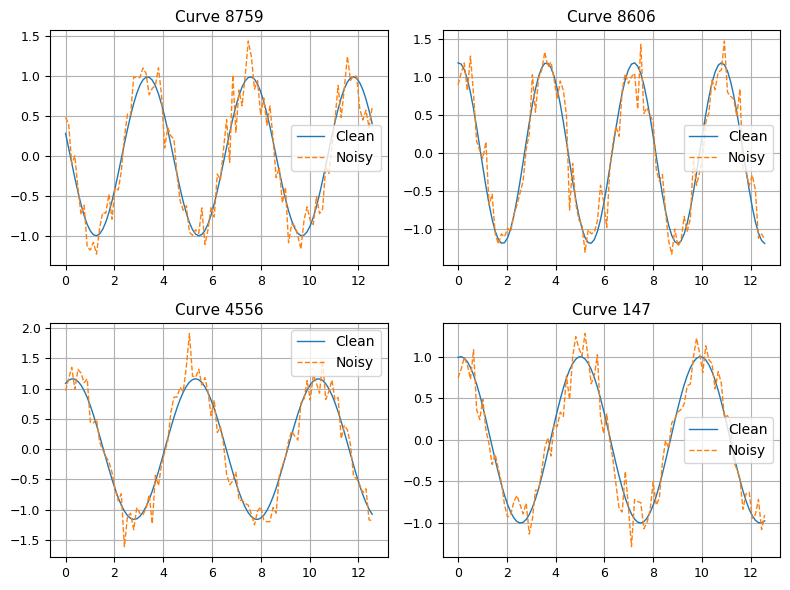

In [63]:
# Plot 4 examples
indices = np.random.choice(N_sin, 4, replace=False)

plt.figure(figsize=(8, 6))

for i, idx in enumerate(indices):
    plt.subplot(2, 2, i+1)
    plt.plot(t, clean_curve[idx], label="Clean", lw=1)
    plt.plot(t, noisy_curve[idx], label="Noisy", lw=1, linestyle="--")
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.title(f"Curve {idx}", fontsize=11)
    plt.legend(loc='best')
    plt.grid()

plt.tight_layout()
plt.savefig('HW08_1a.png', dpi=250, transparent=True)
#plt.show()

In [8]:
num_curves = noisy_curve.shape[0]

# Create shuffled indices
indices = np.random.permutation(num_curves)

# Split index
split = int(0.9 * num_curves)

train_idx = indices[:split]
val_idx = indices[split:]

# Create splits
x_train = noisy_curve[train_idx]
y_train = clean_curve[train_idx]

x_val = noisy_curve[val_idx]
y_val = clean_curve[val_idx]

# Verify shapes
print(x_train.shape, y_train.shape)  # (9000, 100)
print(x_val.shape, y_val.shape)      # (1000, 100)

(9000, 100) (9000, 100)
(1000, 100) (1000, 100)


In [9]:
# Q2 Autoencoder Model
N = 100

autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                6464      
                                                                 
 dense_1 (Dense)             (None, 16)                1040      
                                                                 
 dense_2 (Dense)             (None, 64)                1088      
                                                                 
 dense_3 (Dense)             (None, 100)               6500      
                                                                 
Total params: 15,092
Trainable params: 15,092
Non-trainable params: 0
_________________________________________________________________


In [10]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 [==============================] - 1s 6ms/step - loss: 0.3531 - val_loss: 0.1217
Epoch 2/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0667 - val_loss: 0.0409
Epoch 3/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0293 - val_loss: 0.0203
Epoch 4/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0168 - val_loss: 0.0154
Epoch 5/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0137 - val_loss: 0.0129
Epoch 6/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0116 - val_loss: 0.0111
Epoch 7/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0097 - val_loss: 0.0093
Epoch 8/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0082 - val_loss: 0.0080
Epoch 9/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0072 - val_loss: 0.0074
Epoch 10/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0066 - val_loss: 0.0067
Epoch 11/50
71/71 [

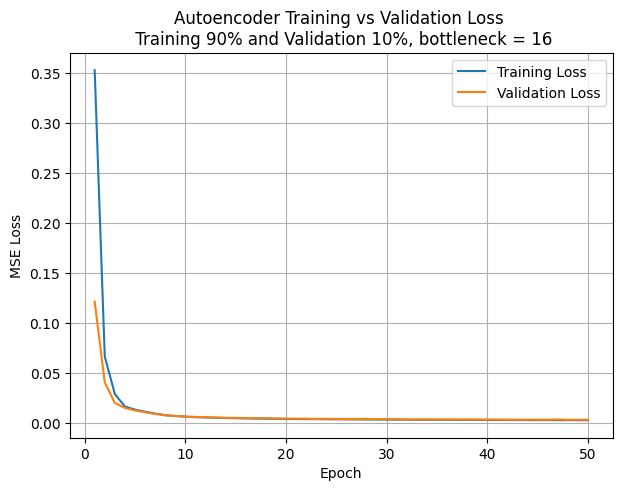

In [64]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training vs Validation Loss \n Training 90% and Validation 10%, bottleneck = 16")
plt.legend()
plt.grid(True)

plt.savefig('HW08_2b.png', dpi=250, transparent=True)

32/32 [==============================] - 0s 3ms/step


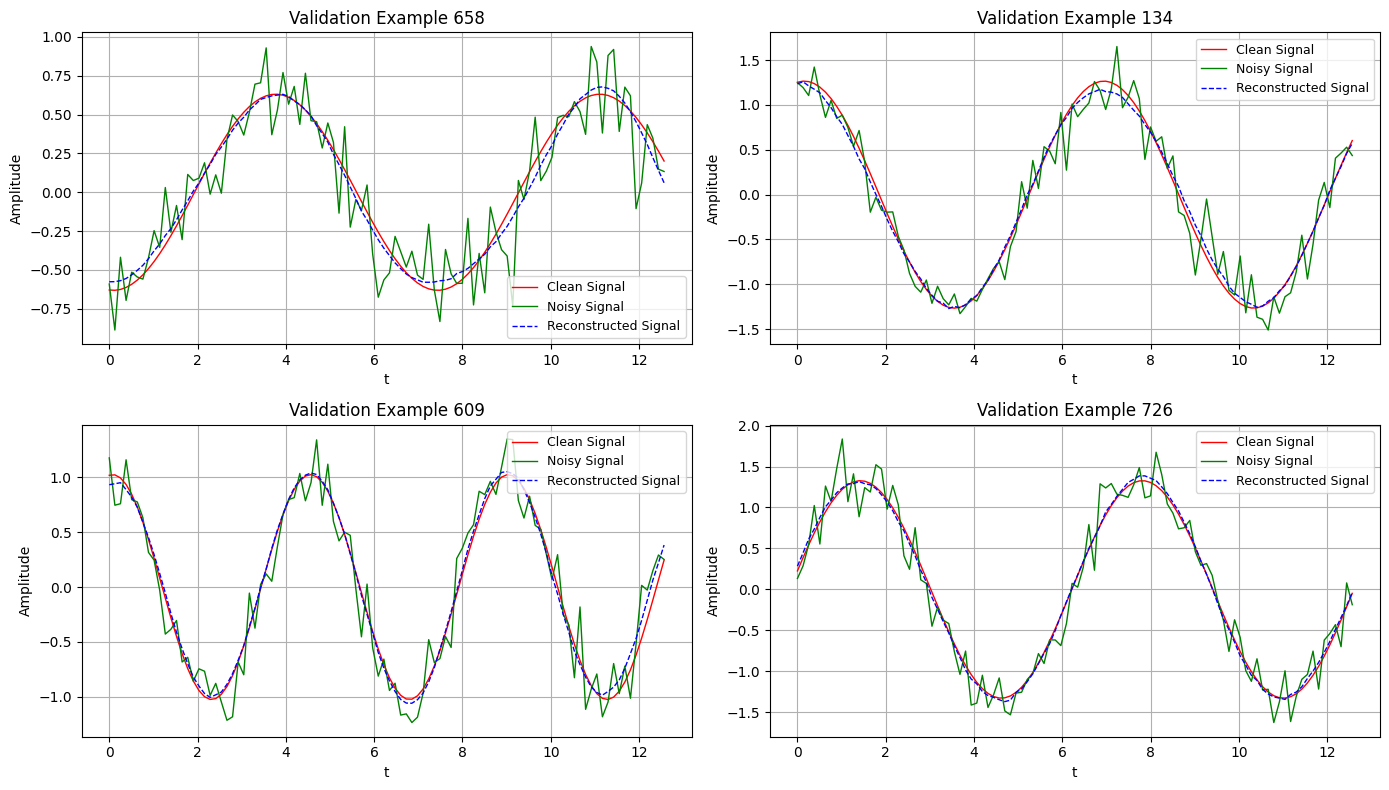

In [78]:
# 2. Plot clean / noisy / reconstructed signals

# Reconstruct validation signals
y_pred = autoencoder.predict(x_val)
#reconstructed_Y = autoencoder.predict(x_val)

# Number of examples to display
num_examples = 4

# Random validation examples
example_idx = np.random.choice(len(x_val), num_examples, replace=False)

# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Flatten axes array for easy looping
axes = axes.flatten()

for i, idx in enumerate(example_idx):
    axes[i].plot(t, y_val[idx], label='Clean Signal', color='red', linewidth=1)
    axes[i].plot(t, x_val[idx], label='Noisy Signal', color='green', lw=1)
    axes[i].plot(t, y_pred[idx], label='Reconstructed Signal', color='blue', linestyle='--', linewidth=1)

    axes[i].set_title(f'Validation Example {idx}')
    axes[i].set_xlabel('t')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='best', fontsize=9)
    axes[i].grid(True)

plt.tight_layout()
#plt.show()
plt.savefig('HW08_2c.png', dpi=250, transparent=True)

In [96]:
# Q3 Parameter Explorartion
# Experiment with different number of training and validation dataset for the same model
num_curves = noisy_curve.shape[0]

# Create shuffled indices
indices = np.random.permutation(num_curves)

# Split index 60% training , 40% validation
split2a = int(0.6 * num_curves)

train_idx2a = indices[:split2a]
val_idx2a = indices[split2a:]

# Create splits
x_train2a = noisy_curve[train_idx2a]
y_train2a = clean_curve[train_idx2a]

x_val2a = noisy_curve[val_idx2a]
y_val2a = clean_curve[val_idx2a]

# Verify shapes
print(x_train2a.shape, y_train2a.shape)  # (6000, 100)
print(x_val2a.shape, y_val2a.shape)      # (4000, 100)

# Model 1 : 100 → 64 → 16 → 64 → 100
# Bottleneck at 16
N = 100

autoencoder2a = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder2a.compile(optimizer=Adam(0.001), loss='mse')
autoencoder2a.summary()

(6000, 100) (6000, 100)
(4000, 100) (4000, 100)
Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_76 (Dense)            (None, 64)                6464      
                                                                 
 dense_77 (Dense)            (None, 16)                1040      
                                                                 
 dense_78 (Dense)            (None, 64)                1088      
                                                                 
 dense_79 (Dense)            (None, 100)               6500      
                                                                 
Total params: 15,092
Trainable params: 15,092
Non-trainable params: 0
_________________________________________________________________


In [97]:
history2a = autoencoder2a.fit(
    x_train2a, y_train2a,
    epochs=50,
    batch_size=128,
    validation_data=(x_val2a, y_val2a),
    verbose=1
)

# extract loss values for plotting
train_loss2a   = history2a.history['loss'] # training loss per epoch
val_loss2a     = history2a.history['val_loss'] # validation loss per epoch
epochs_range2a = range(1, len(train_loss2a) + 1)

Epoch 1/50
47/47 [==============================] - 1s 9ms/step - loss: 0.4411 - val_loss: 0.2667
Epoch 2/50
47/47 [==============================] - 0s 5ms/step - loss: 0.1385 - val_loss: 0.0659
Epoch 3/50
47/47 [==============================] - 0s 5ms/step - loss: 0.0453 - val_loss: 0.0294
Epoch 4/50
47/47 [==============================] - 0s 5ms/step - loss: 0.0229 - val_loss: 0.0191
Epoch 5/50
47/47 [==============================] - 0s 5ms/step - loss: 0.0169 - val_loss: 0.0156
Epoch 6/50
47/47 [==============================] - 0s 5ms/step - loss: 0.0144 - val_loss: 0.0139
Epoch 7/50
47/47 [==============================] - 0s 5ms/step - loss: 0.0127 - val_loss: 0.0124
Epoch 8/50
47/47 [==============================] - 0s 5ms/step - loss: 0.0113 - val_loss: 0.0110
Epoch 9/50
47/47 [==============================] - 0s 6ms/step - loss: 0.0101 - val_loss: 0.0100
Epoch 10/50
47/47 [==============================] - 0s 6ms/step - loss: 0.0091 - val_loss: 0.0090
Epoch 11/50
47/47 [

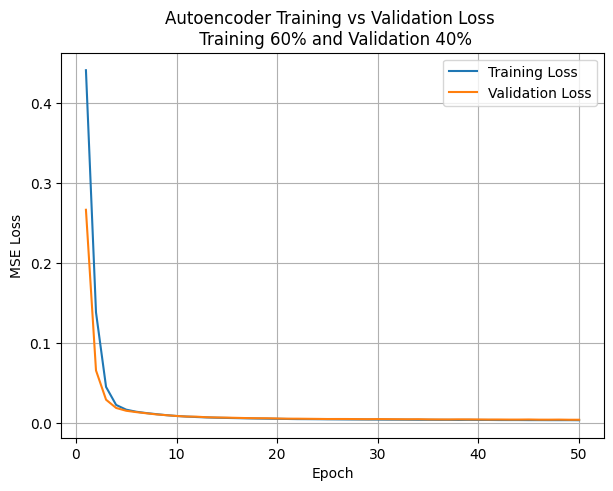

In [98]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range2a, train_loss2a, label="Training Loss")
plt.plot(epochs_range2a, val_loss2a, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training vs Validation Loss \n Training 60% and Validation 40%")
plt.legend()
plt.grid(True)

plt.savefig('HW08_3a6040.png', dpi=250, transparent=True)

In [ ]:
num_curves = noisy_curve.shape[0]

# Create shuffled indices
indices = np.random.permutation(num_curves)

# Split index 30% training , 70% validation
split2b = int(0.3 * num_curves)

train_idx2b = indices[:split2b]
val_idx2b = indices[split2b:]

# Create splits
x_train2b = noisy_curve[train_idx2b]
y_train2b = clean_curve[train_idx2b]

x_val2b = noisy_curve[val_idx2b]
y_val2b = clean_curve[val_idx2b]

# Verify shapes
print(x_train2b.shape, y_train2b.shape)  # (6000, 100)
print(x_val2b.shape, y_val2b.shape)      # (4000, 100)

# Bottleneck at 16
N = 100
autoencoder2b = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder2b.compile(optimizer=Adam(0.001), loss='mse')
autoencoder2b.summary()

(3000, 100) (3000, 100)
(7000, 100) (7000, 100)
Model: "sequential_18"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_80 (Dense)            (None, 64)                6464      
                                                                 
 dense_81 (Dense)            (None, 16)                1040      
                                                                 
 dense_82 (Dense)            (None, 64)                1088      
                                                                 
 dense_83 (Dense)            (None, 100)               6500      
                                                                 
Total params: 15,092
Trainable params: 15,092
Non-trainable params: 0
_________________________________________________________________


In [100]:
history2b = autoencoder2b.fit(
    x_train2b, y_train2b,
    epochs=50,
    batch_size=128,
    validation_data=(x_val2b, y_val2b),
    verbose=1
)

# extract loss values for plotting
train_loss2b   = history2b.history['loss'] # training loss per epoch
val_loss2b     = history2b.history['val_loss'] # validation loss per epoch
epochs_range2b = range(1, len(train_loss2b) + 1)

Epoch 1/50
24/24 [==============================] - 1s 16ms/step - loss: 0.5039 - val_loss: 0.4494
Epoch 2/50
24/24 [==============================] - 0s 8ms/step - loss: 0.3624 - val_loss: 0.2715
Epoch 3/50
24/24 [==============================] - 0s 8ms/step - loss: 0.1910 - val_loss: 0.1261
Epoch 4/50
24/24 [==============================] - 0s 10ms/step - loss: 0.0926 - val_loss: 0.0696
Epoch 5/50
24/24 [==============================] - 0s 10ms/step - loss: 0.0584 - val_loss: 0.0496
Epoch 6/50
24/24 [==============================] - 0s 9ms/step - loss: 0.0408 - val_loss: 0.0335
Epoch 7/50
24/24 [==============================] - 0s 9ms/step - loss: 0.0274 - val_loss: 0.0234
Epoch 8/50
24/24 [==============================] - 0s 10ms/step - loss: 0.0202 - val_loss: 0.0190
Epoch 9/50
24/24 [==============================] - 0s 9ms/step - loss: 0.0173 - val_loss: 0.0174
Epoch 10/50
24/24 [==============================] - 0s 8ms/step - loss: 0.0160 - val_loss: 0.0161
Epoch 11/50
24/

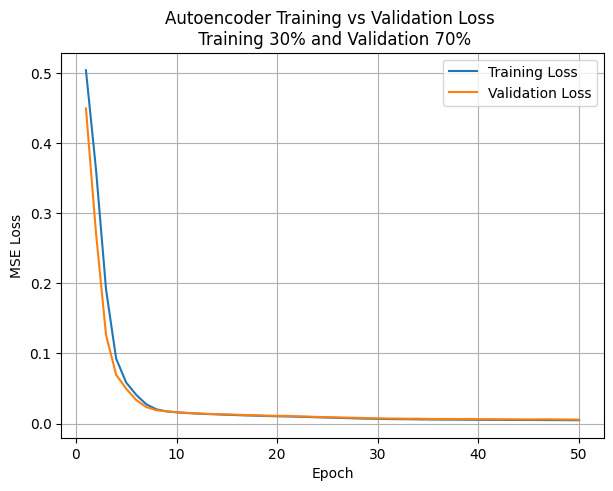

In [101]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range2b, train_loss2b, label="Training Loss")
plt.plot(epochs_range2b, val_loss2b, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training vs Validation Loss \n Training 30% and Validation 70%")
plt.legend()
plt.grid(True)

plt.savefig('HW08_3a3070.png', dpi=250, transparent=True)

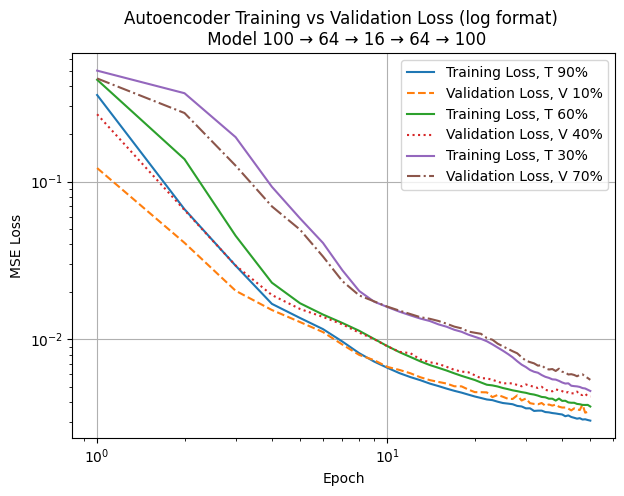

In [152]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range, train_loss, lw=1.5, label="Training Loss, T 90%")
plt.plot(epochs_range, val_loss, ls='--', lw=1.5, label="Validation Loss, V 10%")
plt.plot(epochs_range2a, train_loss2a, lw=1.5, label="Training Loss, T 60%")
plt.plot(epochs_range2a, val_loss2a, ls=':', lw=1.5, label="Validation Loss, V 40%")
plt.plot(epochs_range2b, train_loss2b, lw=1.5, label="Training Loss, T 30%")
plt.plot(epochs_range2b, val_loss2b, ls='-.', lw=1.5, label="Validation Loss, V 70%")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.xscale('log')
plt.yscale('log')
plt.title("Autoencoder Training vs Validation Loss (log format) \n Model 100 → 64 → 16 → 64 → 100")
plt.legend()
plt.grid(True)

plt.savefig('HW08_3acomparisonall_log.png', dpi=250, transparent=True)

In [139]:
# Architecture variation, fixed bottleneck at 4
# Model 1 100 → 64 → 4 → 64 → 100, 90% traning 10% validation
N = 100
autoencoder3a = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder3a.compile(optimizer=Adam(0.001), loss='mse')
autoencoder3a.summary()

start_time3a = time.time()
history3a = autoencoder3a.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
training_time3a = time.time() - start_time3a

# extract loss values for plotting
train_loss3a   = history3a.history['loss'] # training loss per epoch
val_loss3a     = history3a.history['val_loss'] # validation loss per epoch
epochs_range3a = range(1, len(train_loss3a) + 1)
final_val_mse3a  = history3a.history['val_loss'][-1]
print(f"Final Validation MSE: {final_val_mse3a:.5f}")
print(f"Training Time: {training_time3a:.3f} s")

Model: "sequential_38"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_166 (Dense)           (None, 64)                6464      
                                                                 
 dense_167 (Dense)           (None, 4)                 260       
                                                                 
 dense_168 (Dense)           (None, 64)                320       
                                                                 
 dense_169 (Dense)           (None, 100)               6500      
                                                                 
Total params: 13,544
Trainable params: 13,544
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
71/71 [==============================] - 1s 8ms/step - loss: 0.4357 - val_loss: 0.2833
Epoch 2/50
71/71 [==============================] - 0s 6ms/step - loss: 0.2340 - va

In [140]:
# Architecture variation, fixed bottleneck at 4
# Model 2 100 → 80 → 40 → 4 → 40 → 80 → 100, 90% traning 10% validation
N = 100
autoencoder3b = Sequential([
    Input(shape=(N,)),
    Dense(80, activation='relu'),
    Dense(40, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(40, activation='relu'),
    Dense(80, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder3b.compile(optimizer=Adam(0.001), loss='mse')
autoencoder3b.summary()

start_time3b = time.time()
history3b = autoencoder3b.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
training_time3b = time.time() - start_time3b

# extract loss values for plotting
train_loss3b   = history3b.history['loss'] # training loss per epoch
val_loss3b     = history3b.history['val_loss'] # validation loss per epoch
epochs_range3b = range(1, len(train_loss3b) + 1)
final_val_mse3b  = history3b.history['val_loss'][-1]
print(f"Final Validation MSE: {final_val_mse3b:.5f}")
print(f"Training Time: {training_time3b:.3f} s")

Model: "sequential_39"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_170 (Dense)           (None, 80)                8080      
                                                                 
 dense_171 (Dense)           (None, 40)                3240      
                                                                 
 dense_172 (Dense)           (None, 4)                 164       
                                                                 
 dense_173 (Dense)           (None, 40)                200       
                                                                 
 dense_174 (Dense)           (None, 80)                3280      
                                                                 
 dense_175 (Dense)           (None, 100)               8100      
                                                                 
Total params: 23,064
Trainable params: 23,064
Non-tra

In [141]:
# Architecture variation, fixed bottleneck at 4
# Model 3 100 → 64 → 32 → 16 → 4 → 16 → 32 → 64 → 100, 90% traning 10% validation
N = 100
autoencoder3c = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder3c.compile(optimizer=Adam(0.001), loss='mse')
autoencoder3c.summary()

start_time3c = time.time()
history3c = autoencoder3c.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
training_time3c = time.time() - start_time3c

# extract loss values for plotting
train_loss3c   = history3c.history['loss'] # training loss per epoch
val_loss3c     = history3c.history['val_loss'] # validation loss per epoch
epochs_range3c = range(1, len(train_loss3c) + 1)
final_val_mse3c  = history3c.history['val_loss'][-1]
print(f"Final Validation MSE: {final_val_mse3c:.5f}")
print(f"Training Time: {training_time3c:.3f} s")

Model: "sequential_40"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_176 (Dense)           (None, 64)                6464      
                                                                 
 dense_177 (Dense)           (None, 32)                2080      
                                                                 
 dense_178 (Dense)           (None, 16)                528       
                                                                 
 dense_179 (Dense)           (None, 4)                 68        
                                                                 
 dense_180 (Dense)           (None, 16)                80        
                                                                 
 dense_181 (Dense)           (None, 32)                544       
                                                                 
 dense_182 (Dense)           (None, 64)              

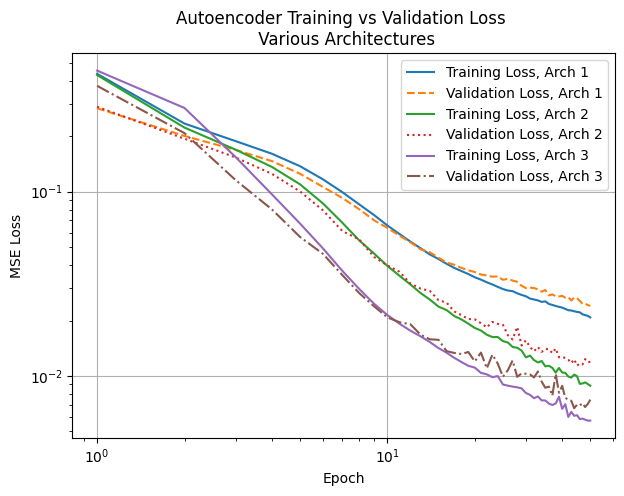

In [149]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range3a, train_loss3a, lw=1.5, label="Training Loss, Arch 1")
plt.plot(epochs_range3a, val_loss3a, ls='--', lw=1.5, label="Validation Loss, Arch 1")
plt.plot(epochs_range3b, train_loss3b, lw=1.5, label="Training Loss, Arch 2")
plt.plot(epochs_range3b, val_loss3b, ls=':', lw=1.5, label="Validation Loss, Arch 2")
plt.plot(epochs_range3c, train_loss3c, lw=1.5, label="Training Loss, Arch 3")
plt.plot(epochs_range3c, val_loss3c, ls='-.', lw=1.5, label="Validation Loss, Arch 3")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.xscale('log')
plt.yscale('log')
plt.title("Autoencoder Training vs Validation Loss \n Various Architectures")
plt.legend()
plt.grid(True)

plt.savefig('HW08_3bcomparisonArch.png', dpi=250, transparent=True)

In [137]:
# Varying the bottle neck 16, 8, 4, 3, 2, 1
# Using model 1 from the previous part (3b)
# 90% traning 10% validation

N = 100
bottleneck = 1
autoencoder3d = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(1, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder3d.compile(optimizer=Adam(0.001), loss='mse')
autoencoder3d.summary()

start_time3d = time.time()
history3d = autoencoder3d.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)
training_time3d = time.time() - start_time3d

# extract loss values for plotting
train_loss3d   = history3d.history['loss'] # training loss per epoch
val_loss3d     = history3d.history['val_loss'] # validation loss per epoch
epochs_range3d = range(1, len(train_loss3d) + 1)
final_val_mse3d  = history3d.history['val_loss'][-1]
print(f"Final Validation MSE: {final_val_mse3d:.5f}")
print(f"Training Time (bottleneck = {bottleneck}): {training_time3d:.3f} s")

Model: "sequential_37"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_162 (Dense)           (None, 64)                6464      
                                                                 
 dense_163 (Dense)           (None, 1)                 65        
                                                                 
 dense_164 (Dense)           (None, 64)                128       
                                                                 
 dense_165 (Dense)           (None, 100)               6500      
                                                                 
Total params: 13,157
Trainable params: 13,157
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
71/71 [==============================] - 1s 7ms/step - loss: 0.5025 - val_loss: 0.4885
Epoch 2/50
71/71 [==============================] - 0s 4ms/step - loss: 0.4788 - va

In [124]:
history3d

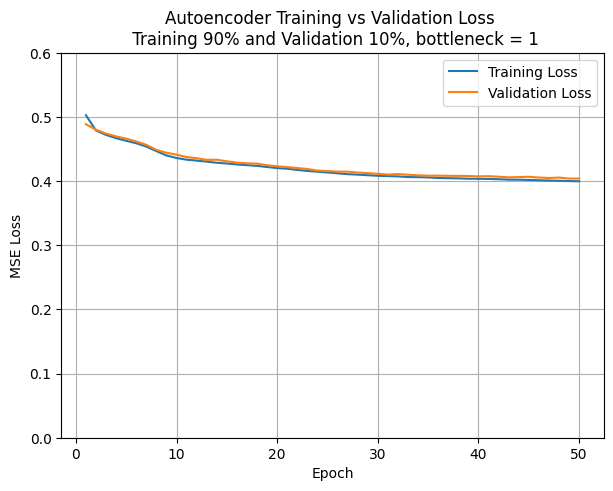

In [138]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range3d, train_loss3d, label="Training Loss")
plt.plot(epochs_range3d, val_loss3d, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.ylim(0,0.6)
plt.title(f"Autoencoder Training vs Validation Loss \n Training 90% and Validation 10%, bottleneck = {bottleneck}")
plt.legend()
plt.grid(True)

plt.savefig('HW08_3_bottleneck1.png', dpi=250, transparent=True)

32/32 [==============================] - 0s 2ms/step


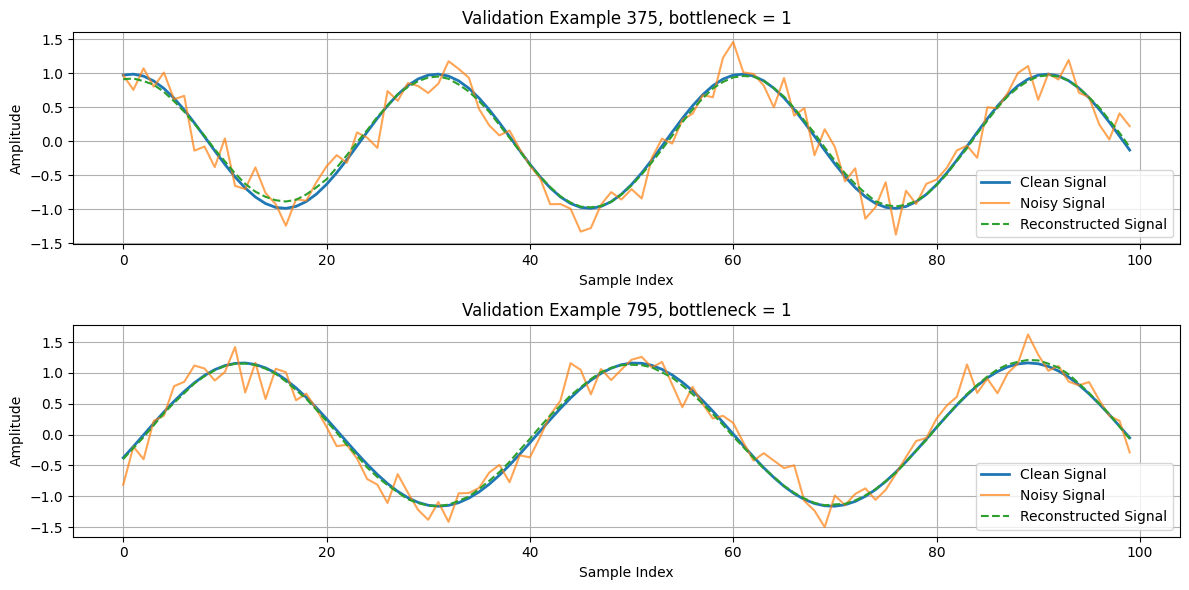

In [60]:
# Plot clean / noisy / reconstructed signals

# Reconstruct validation signals
y_pred4 = autoencoder.predict(x_val4)
#reconstructed_Y = autoencoder.predict(x_val)

# Number of examples to display
num_examples = 2

# Random validation examples
example_idx4 = np.random.choice(len(x_val4), num_examples, replace=False)

fig, axes = plt.subplots(num_examples, 1, figsize=(12, 3*num_examples))

# Handle case where num_examples = 1
if num_examples == 1:
    axes = [axes]

for i, idx in enumerate(example_idx4):

    axes[i].plot(y_val4[idx], label='Clean Signal', linewidth=2)
    axes[i].plot(x_val4[idx], label='Noisy Signal', alpha=0.7)
    axes[i].plot(y_pred4[idx], label='Reconstructed Signal', linestyle='--')

    axes[i].set_title(f'Validation Example {idx}, bottleneck = {bottleneck}')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()

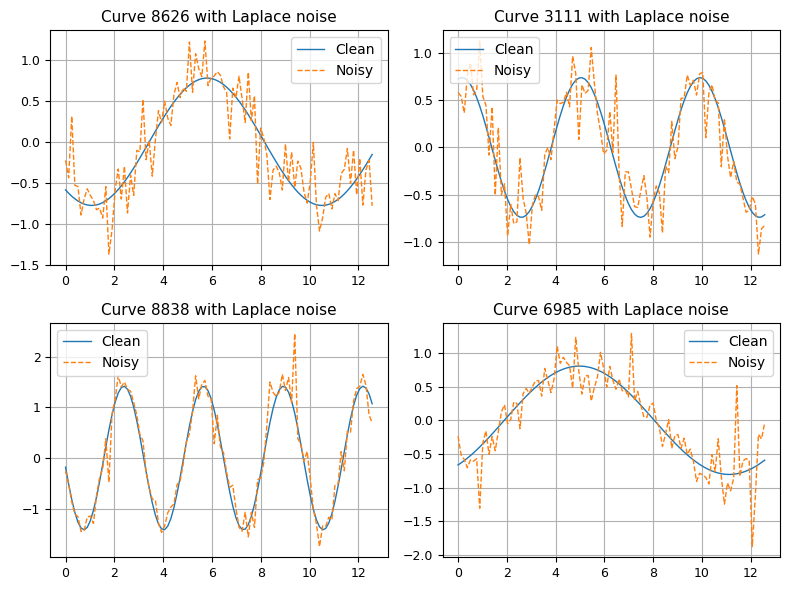

In [180]:
# Laplace noise
scale = 0.2

noise_laplace = np.random.laplace(loc=0,scale=scale,size=(N_sin, N_sample))

noisy_curve_laplace = clean_curve + noise_laplace

# Plot 4 examples
indices_laplace = np.random.choice(N_sin, 4, replace=False)

plt.figure(figsize=(8, 6))

for i, idx in enumerate(indices_laplace):
    plt.subplot(2, 2, i+1)
    plt.plot(t, clean_curve[idx], label="Clean", lw=1)
    plt.plot(t, noisy_curve_laplace[idx], label="Noisy", lw=1, linestyle="--")
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9)
    plt.title(f"Curve {idx} with Laplace noise", fontsize=11)
    plt.legend(loc='best')
    plt.grid()

plt.tight_layout()
plt.savefig('HW08_3_laplace.png', dpi=250, transparent=True)
#plt.show()

In [175]:
num_curves = noisy_curve_laplace.shape[0]

# Create shuffled indices
indices_laplace2 = np.random.permutation(num_curves)

# Split index
split_laplace = int(0.9 * num_curves)

train_idx_laplace = indices_laplace2[:split_laplace]
val_idx_laplace = indices_laplace2[split_laplace:]

# Create splits
x_train_laplace = noisy_curve_laplace[train_idx_laplace]
y_train_laplace = clean_curve[train_idx_laplace]

x_val_laplace = noisy_curve_laplace[val_idx_laplace]
y_val_laplace = clean_curve[val_idx_laplace]

# Verify shapes
print(x_train_laplace.shape, y_train_laplace.shape)  # (9000, 100)
print(x_val_laplace.shape, y_val_laplace.shape)      # (1000, 100)

(9000, 100) (9000, 100)
(1000, 100) (1000, 100)


In [176]:
N = 100
autoencoder_laplace = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder_laplace.compile(optimizer=Adam(0.001), loss='mse')
autoencoder_laplace.summary()

Model: "sequential_46"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_204 (Dense)           (None, 64)                6464      
                                                                 
 dense_205 (Dense)           (None, 16)                1040      
                                                                 
 dense_206 (Dense)           (None, 64)                1088      
                                                                 
 dense_207 (Dense)           (None, 100)               6500      
                                                                 
Total params: 15,092
Trainable params: 15,092
Non-trainable params: 0
_________________________________________________________________


In [177]:
start_time_laplace = time.time()
history_laplace = autoencoder.fit(
    x_train_laplace, y_train_laplace,
    epochs=50,
    batch_size=128,
    validation_data=(x_val_laplace, y_val_laplace),
    verbose=1
)

training_time_laplace = time.time() - start_time_laplace

# extract loss values for plotting
train_loss_laplace   = history_laplace.history['loss'] # training loss per epoch
val_loss_laplace     = history_laplace.history['val_loss'] # validation loss per epoch
epochs_range_laplace = range(1, len(train_loss_laplace) + 1)
final_val_laplace = history_laplace.history['val_loss'][-1]
print(f"Final Validation MSE: {final_val_laplace:.5f}")
print(f"Training Time: {training_time_laplace:.3f} s")

Epoch 1/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0043 - val_loss: 0.0045
Epoch 2/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0042 - val_loss: 0.0043
Epoch 3/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0041 - val_loss: 0.0043
Epoch 4/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0040 - val_loss: 0.0043
Epoch 5/50
71/71 [==============================] - 0s 4ms/step - loss: 0.0039 - val_loss: 0.0041
Epoch 6/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0038 - val_loss: 0.0042
Epoch 7/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0038 - val_loss: 0.0042
Epoch 8/50
71/71 [==============================] - 0s 2ms/step - loss: 0.0038 - val_loss: 0.0041
Epoch 9/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0037 - val_loss: 0.0042
Epoch 10/50
71/71 [==============================] - 0s 3ms/step - loss: 0.0037 - val_loss: 0.0042
Epoch 11/50
71/71 [

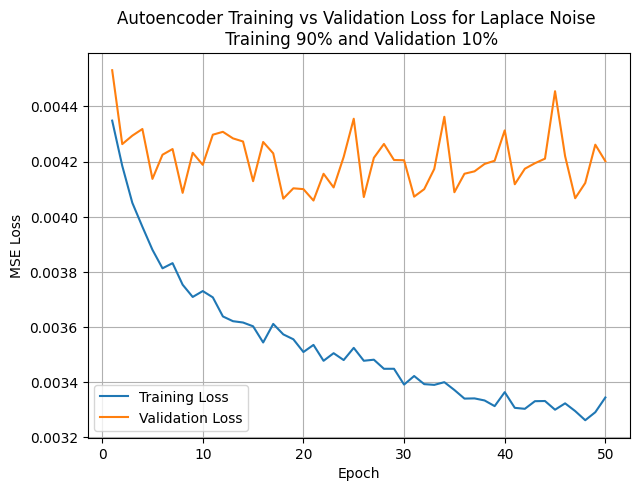

In [179]:
plt.figure(figsize=(7, 5))

plt.plot(epochs_range_laplace, train_loss_laplace, label="Training Loss")
plt.plot(epochs_range_laplace, val_loss_laplace, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training vs Validation Loss for Laplace Noise \n Training 90% and Validation 10%")
plt.legend()
plt.grid(True)

plt.savefig('HW08_3_TVlaplace.png', dpi=250, transparent=True)